# DSN Mart Sales Prediction — DSN AI Bootcamp 2026 Qualification Hackathon

**Goal:** predict `total_sales` for a given product at a given store.
**Metric:** RMSE (lower is better).

**Pipeline (one straight pass):** load → explore → clean → impute → engineer
features → encode → tune → train final model → predict → submit.

This consolidates what used to be a "v1 baseline, then v2 tuned" comparison
into a single workflow: every feature and cleaning step below is used by the
one model that gets tuned and submitted. Notes on earlier bug fixes carried
into this version:

- Portable relative data paths instead of a hardcoded Windows path.
- `fat_content` abbreviations (`LF`, `reg`, ...) are explicitly mapped —
  title-casing alone doesn't merge them into `Low Fat` / `Regular`.
- Grid search covers `max_depth` in `[4, 6, 8]` (previously `6` was
  duplicated and `8` was never tested).
- Output folder is created automatically before saving.
- One `submission.csv` at the end — no leftover `_v1`/`_v2` files to mix up.


In [1]:
import os
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')



RANDOM_STATE = 42

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print('train:', train.shape)
print('test:', test.shape)
train.head()

train: (6818, 13)
test: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## 1. First look at the data

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [4]:
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [5]:
# Missing values
print('--- Train missing ---')
print(train.isnull().sum()[train.isnull().sum() > 0])
print()
print('--- Test missing ---')
print(test.isnull().sum()[test.isnull().sum() > 0])

--- Train missing ---
product_weight_kg    1225
store_size           1919
dtype: int64

--- Test missing ---
product_weight_kg    306
store_size           491
dtype: int64


## 2. Cleaning up messy categories

`product_category` (and a few other text columns) have inconsistent casing —
`Dairy`, `dairy`, `DAIRY` are currently treated as different categories.
Standardizing casing handles that.

`fat_content` has a second, separate problem: casing *and* abbreviations
(`Low Fat`, `low fat`, `LF`, `Regular`, `reg` are all meant to be one of two
values). Casing alone won't merge `LF` into `Low Fat`, so that gets an
explicit mapping.

In [6]:
FAT_CONTENT_MAP = {
    'lf': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular',
    'regular': 'Regular',
}

def clean_category(df):
    df = df.copy()
    df['product_category'] = df['product_category'].str.strip().str.title()
    df['store_size'] = df['store_size'].str.strip().str.title()
    df['store_location_tier'] = df['store_location_tier'].str.strip()
    df['store_format'] = df['store_format'].str.strip().str.title()

    # fat_content needs abbreviation handling on top of casing, otherwise
    # 'LF' and 'Low Fat' stay as two different categories.
    df['fat_content'] = (
        df['fat_content']
        .str.strip()
        .str.lower()
        .map(FAT_CONTENT_MAP)
        .fillna(df['fat_content'].str.strip().str.title())
    )
    return df

train = clean_category(train)
test = clean_category(test)

print(sorted(train['product_category'].unique()))
print('n categories after cleaning:', train['product_category'].nunique())
print('fat_content values:', sorted(train['fat_content'].unique()))

['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy', 'Frozen Foods', 'Fruits And Vegetables', 'Hard Drinks', 'Health And Hygiene', 'Household', 'Meat', 'Others', 'Seafood', 'Snack Foods', 'Soft Drinks', 'Starchy Foods']
n categories after cleaning: 16
fat_content values: ['Low Fat', 'Regular']


## 3. Exploratory data analysis

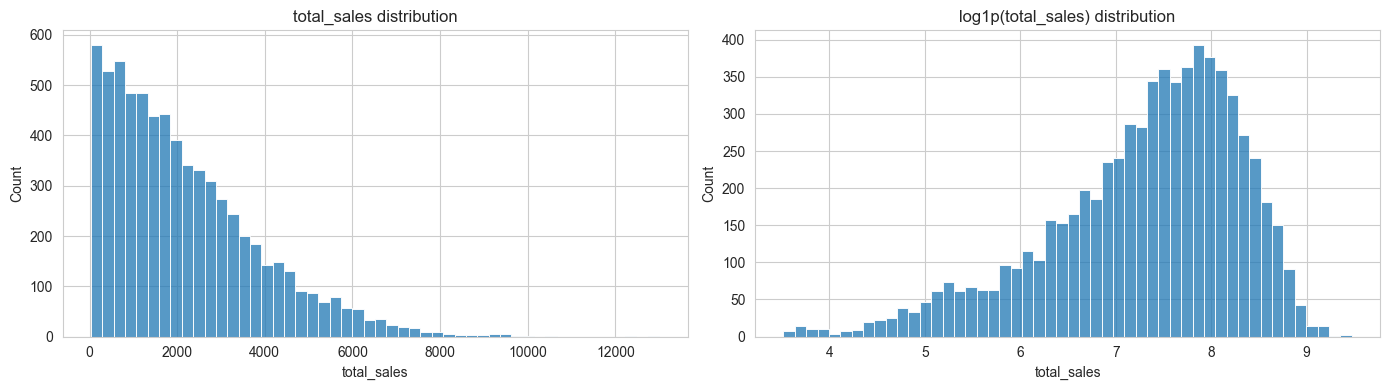

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(train['total_sales'], bins=50, ax=axes[0])
axes[0].set_title('total_sales distribution')
sns.histplot(np.log1p(train['total_sales']), bins=50, ax=axes[1])
axes[1].set_title('log1p(total_sales) distribution')
plt.tight_layout()
plt.show()

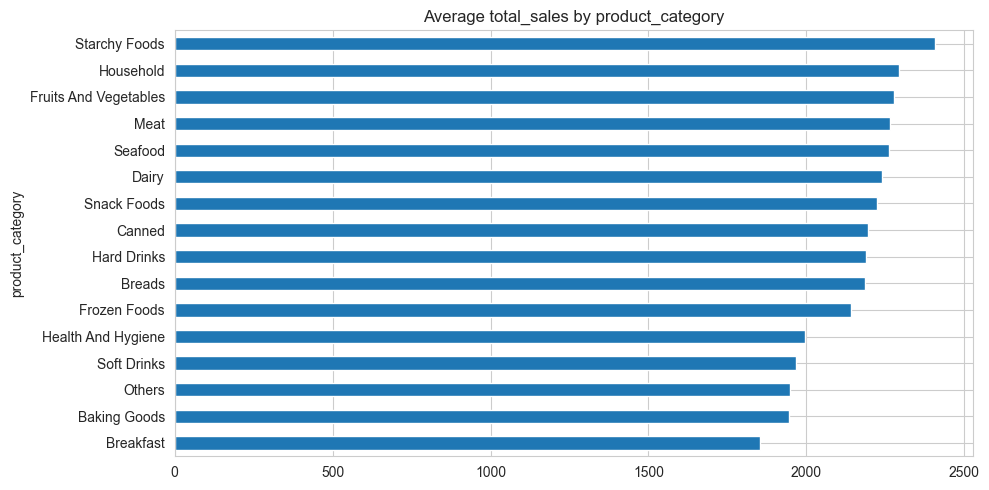

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
train.groupby('product_category')['total_sales'].mean().sort_values().plot(kind='barh', ax=ax)
ax.set_title('Average total_sales by product_category')
plt.tight_layout()
plt.show()

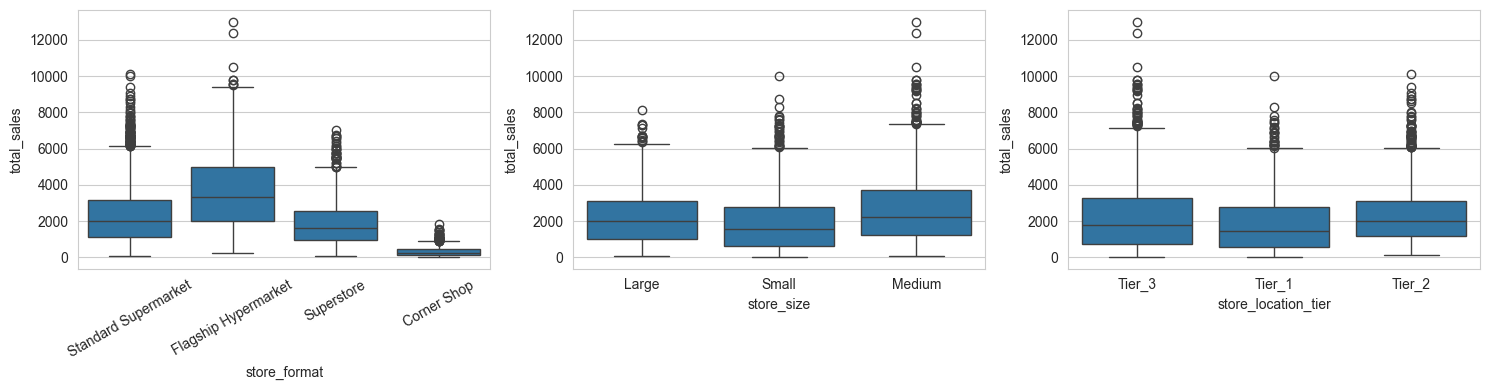

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=train, x='store_format', y='total_sales', ax=axes[0])
axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=train, x='store_size', y='total_sales', ax=axes[1])
sns.boxplot(data=train, x='store_location_tier', y='total_sales', ax=axes[2])
plt.tight_layout()
plt.show()

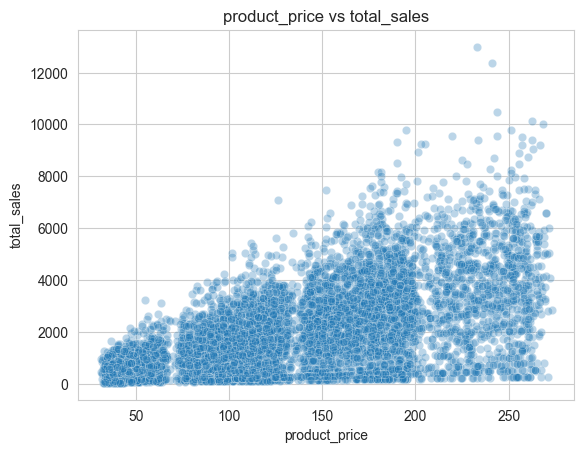

In [10]:
sns.scatterplot(data=train, x='product_price', y='total_sales', alpha=0.3)
plt.title('product_price vs total_sales')
plt.show()

## 4. Handling missing values

- `product_weight_kg`: impute using the median weight *for that product*
  (same product code should weigh the same across stores), falling back to
  the overall median if a product never appears with a known weight.
- `store_size`: impute using the mode `store_size` *for that store* (a
  store's size shouldn't change row to row), falling back to the overall
  mode.

In [11]:
combined = pd.concat(
    [train.assign(is_train=1), test.assign(is_train=0, total_sales=np.nan)],
    ignore_index=True,
)

# product_weight_kg: fill by product_code median, then global median
combined['product_weight_kg'] = combined.groupby('product_code')['product_weight_kg'] \
    .transform(lambda x: x.fillna(x.median()))
combined['product_weight_kg'] = combined['product_weight_kg'].fillna(
    combined['product_weight_kg'].median()
)

# store_size: fill by store_code mode, then global mode
def fill_mode(x):
    mode = x.mode()
    return x.fillna(mode.iloc[0]) if not mode.empty else x

combined['store_size'] = combined.groupby('store_code')['store_size'].transform(fill_mode)
combined['store_size'] = combined['store_size'].fillna(combined['store_size'].mode().iloc[0])

print(combined.isnull().sum()[combined.isnull().sum() > 0])

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


total_sales    1705
dtype: int64


## 5. Feature engineering

All engineered features used by the final model, built in one pass:

- `category_avg_price`, `price_vs_category_avg` — price relative to its
  category's average.
- `store_avg_price` — a store-level price aggregate.
- `store_age_bucket` — `store_age_years` binned, in case the relationship
  with sales isn't linear.
- `shelf_visibility_clean` — 422 of 6,818 rows (~6%) have `shelf_visibility`
  at exactly 0, which is implausible for a product actually on a shelf.
  Treated as missing and imputed with the category average.
- `price_per_kg` — value density (price relative to weight).
- `store_format_category_avg` — average price of a category within a given
  store format.

Note: these aggregates are computed over `train + test` combined. That's a
mild form of leakage (test-set values shape a feature used in training) —
it doesn't touch the target, since `product_price` etc. are known for test
rows too, but a stricter setup would fit aggregates on train only and map
them onto test. Left as-is here for simplicity.

In [12]:
combined['category_avg_price'] = combined.groupby('product_category')['product_price'].transform('mean')
combined['price_vs_category_avg'] = combined['product_price'] / combined['category_avg_price']
combined['store_avg_price'] = combined.groupby('store_code')['product_price'].transform('mean')

combined['store_age_bucket'] = pd.cut(
    combined['store_age_years'], bins=[0, 28, 35, 45, 100],
    labels=['New', 'Mid', 'Established', 'Old'],
)

combined['shelf_visibility_clean'] = combined['shelf_visibility'].replace(0, np.nan)
combined['shelf_visibility_clean'] = combined.groupby('product_category')['shelf_visibility_clean'] \
    .transform(lambda x: x.fillna(x.mean()))

combined['price_per_kg'] = combined['product_price'] / combined['product_weight_kg']

combined['store_format_category_avg'] = combined.groupby(
    ['store_format', 'product_category']
)['product_price'].transform('mean')

combined.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,is_train,category_avg_price,price_vs_category_avg,store_avg_price,store_age_bucket,shelf_visibility_clean,price_per_kg,store_format_category_avg
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,1,138.600864,0.587081,141.355376,Established,0.0271,5.709374,138.771364
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,1,130.811635,0.321455,142.169022,Mid,0.0720,5.462458,131.408507
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,1,139.720924,0.295947,140.385796,Mid,0.0421,2.898906,140.011455
3,row_00003,PRD-UN5Z3J,12.665,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,1,131.574180,1.325108,139.763176,Old,0.0449,13.766285,123.628889
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,1,139.876212,1.451712,143.052656,New,0.0120,19.642097,140.728482


## 6. Encode categoricals and split back into train/test

In [13]:
cat_cols = [
    'fat_content', 'product_category', 'store_size', 'store_location_tier',
    'store_format', 'store_code', 'store_age_bucket',
]
# shelf_visibility is dropped in favor of the cleaned version built above
drop_cols = ['id', 'product_code', 'store_code', 'is_train', 'shelf_visibility']

model_df = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

feature_cols = [c for c in model_df.columns if c not in drop_cols + ['total_sales']]

train_model = model_df[model_df['is_train'] == 1].reset_index(drop=True)
test_model = model_df[model_df['is_train'] == 0].reset_index(drop=True)

X = train_model[feature_cols]
y = train_model['total_sales']
X_test = test_model[feature_cols]

print(X.shape, X_test.shape)

(6818, 44) (1705, 44)


## 7. Sanity-check split: does a plain RandomForest even work here?

Before tuning, fit one untuned model on a hold-out split just to confirm the
pipeline runs end to end and get a rough RMSE to tune against.

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

sanity_model = RandomForestRegressor(
    n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1
)
sanity_model.fit(X_train, y_train)

val_preds = sanity_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f'Untuned hold-out RMSE: {rmse:.2f}')

Untuned hold-out RMSE: 1091.66


## 8. Tune RandomForest regularization with 5-fold CV

In [15]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Quick scan with fewer trees on 3-fold CV first (faster) -- the winner gets
# confirmed properly with the full 5-fold, 300-tree setting in the next cell.
kf_search = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [1, 10, 20],
    'max_features': [1.0, 0.5],
}

results = []
for max_depth, min_samples_leaf, max_features in product(
    param_grid['max_depth'], param_grid['min_samples_leaf'], param_grid['max_features']
):
    params = dict(
        n_estimators=150, max_depth=max_depth,
        min_samples_leaf=min_samples_leaf, max_features=max_features,
    )
    scores = []
    for train_idx, val_idx in kf_search.split(X):
        m = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = m.predict(X.iloc[val_idx])
        scores.append(np.sqrt(mean_squared_error(y.iloc[val_idx], preds)))
    results.append({**params, 'rmse_mean': np.mean(scores), 'rmse_std': np.std(scores)})

results_df = pd.DataFrame(results).sort_values('rmse_mean')
results_df.head(10)

,n_estimators,max_depth,min_samples_leaf,max_features,rmse_mean,rmse_std
11,150,6,20,0.5,1082.440567,10.998369
10,150,6,20,1.0,1083.022013,10.284826
9,150,6,10,0.5,1083.084427,10.326898
17,150,8,20,0.5,1083.738046,12.565275
8,150,6,10,1.0,1084.006060,10.062433
7,150,6,1,0.5,1084.337176,9.169459
6,150,6,1,1.0,1085.623920,8.625995
15,150,8,10,0.5,1086.488667,11.539091
16,150,8,20,1.0,1087.095843,11.330464
13,150,8,1,0.5,1090.385753,9.777381


## 9. Confirm the winner with the full 5-fold CV, 300 trees

In [16]:
best_params = results_df.iloc[0][['max_depth', 'min_samples_leaf', 'max_features']].to_dict()
best_params['max_depth'] = int(best_params['max_depth'])
best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
best_params['n_estimators'] = 300  # match the sanity-check tree count for a fair comparison

untuned_params = dict(n_estimators=300, max_depth=8)
untuned_scores, tuned_scores = [], []
for train_idx, val_idx in kf.split(X):
    m_untuned = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **untuned_params)
    m_untuned.fit(X.iloc[train_idx], y.iloc[train_idx])
    untuned_scores.append(
        np.sqrt(mean_squared_error(y.iloc[val_idx], m_untuned.predict(X.iloc[val_idx])))
    )

    m_tuned = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
    m_tuned.fit(X.iloc[train_idx], y.iloc[train_idx])
    tuned_scores.append(
        np.sqrt(mean_squared_error(y.iloc[val_idx], m_tuned.predict(X.iloc[val_idx])))
    )

print(f'Untuned {untuned_params}: {np.mean(untuned_scores):.2f} (+/- {np.std(untuned_scores):.2f})')
print(f'Tuned {best_params}: {np.mean(tuned_scores):.2f} (+/- {np.std(tuned_scores):.2f})')

Untuned {'n_estimators': 300, 'max_depth': 8}: 1089.61 (+/- 23.59)
Tuned {'max_depth': 6, 'min_samples_leaf': 20, 'max_features': 0.5, 'n_estimators': 300}: 1080.89 (+/- 19.23)


**Result:** forcing the trees to be shallower and each leaf to require more
samples (`min_samples_leaf=20` instead of the default `1`) stops the model
from memorizing tiny groups of training rows. This improves RMSE **and** reduces the fold-to-fold standard deviation — a more
consistent model, not just a luckier average.

## 10. Train the final model on full data and predict

In [19]:
final_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
final_model.fit(X, y)

test_preds = final_model.predict(X_test)
test_preds = np.clip(test_preds, 0, None)  # sales can't be negative

submission = pd.DataFrame({
    'id': test_model['id'],
    'total_sales': test_preds,
})

submission.to_csv('submission.csv', index=False)
print(f'Submission saved')
submission.head()

Submission saved


,id,total_sales
0,row_00009,2820.663921
1,row_00015,4113.203246
2,row_00019,3149.600557
3,row_00020,3198.029978
4,row_00023,2505.564059


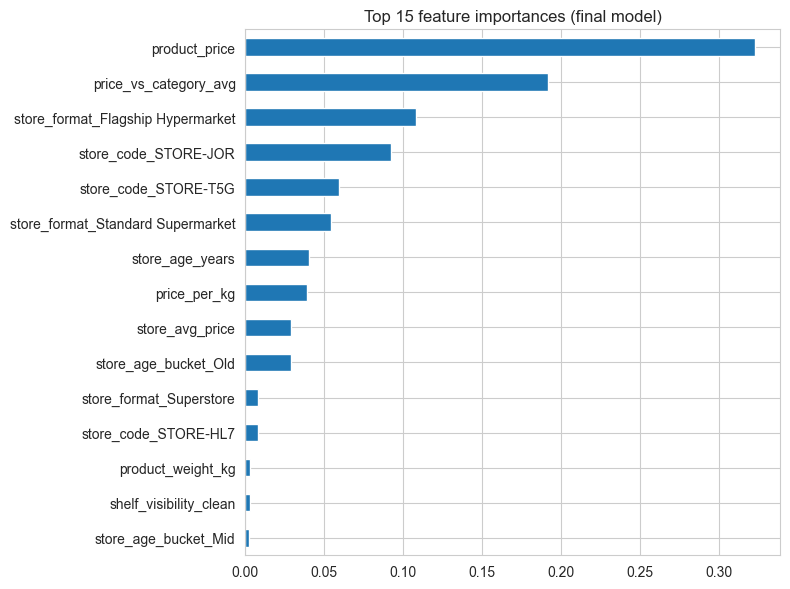

In [20]:
importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances (final model)')
plt.tight_layout()
plt.show()